<a href="https://colab.research.google.com/github/sagar-kc7/pytorch_fundamentals/blob/main/02_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

## 1. Data Preprocessing

### Basic Concept

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Spliting Data

In [3]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Build Model

In [4]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [5]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [6]:
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [7]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

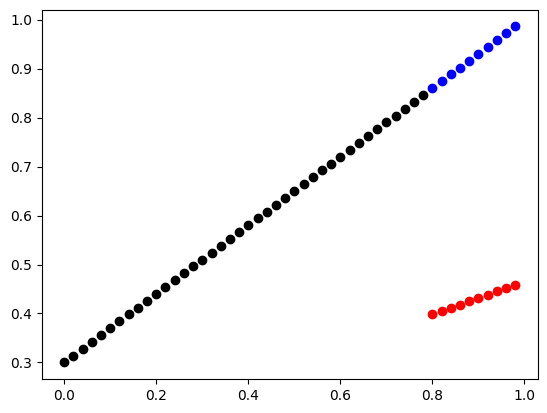

In [8]:
plt.scatter(X_train, y_train, c='black')
plt.scatter(X_test, y_test, c='blue')
plt.scatter(X_test, y_preds, c='red')

plt.show()

*Red points are predected points.*

## Train Model

### Loss function and Optimizer
* MAE
* SGD

In [9]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

### Training loop

In [16]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_0.train()

  y_preds = model_0(X_train)

  loss = loss_fn(y_preds, y_train)
  print(f"Loss: {loss}")

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

model_0.state_dict()

Loss: 0.024110013619065285
Loss: 0.02376994863152504
Loss: 0.02342480979859829
Loss: 0.023080935701727867
Loss: 0.022739607840776443
Loss: 0.022391926497220993
Loss: 0.022054409608244896
Loss: 0.02170540764927864
Loss: 0.021366719156503677
Loss: 0.021020207554101944
Loss: 0.020677709951996803
Loss: 0.02033500373363495
Loss: 0.01998869702219963
Loss: 0.019649803638458252
Loss: 0.019300809130072594
Loss: 0.018963487818837166
Loss: 0.01861560344696045
Loss: 0.018274478614330292
Loss: 0.017930403351783752
Loss: 0.01758546568453312
Loss: 0.017245199531316757
Loss: 0.016896454617381096
Loss: 0.01656000316143036
Loss: 0.016210997477173805
Loss: 0.01587124727666378
Loss: 0.015525798313319683
Loss: 0.015182236209511757
Loss: 0.014840595424175262
Loss: 0.01449323259294033
Loss: 0.014155393466353416
Loss: 0.013806397095322609
Loss: 0.013468016870319843
Loss: 0.013121193274855614
Loss: 0.01277900766581297
Loss: 0.012435992248356342
Loss: 0.01208999752998352
Loss: 0.011750795878469944
Loss: 0.01140

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [18]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

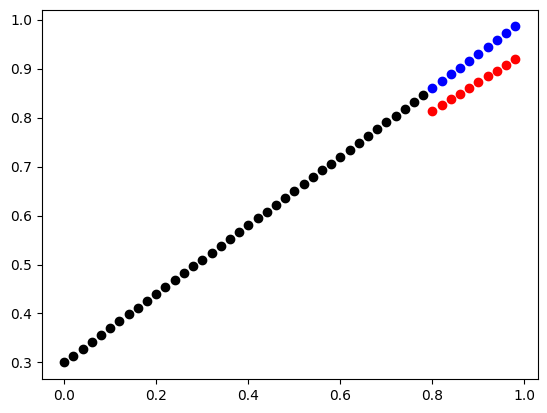

In [15]:
plt.scatter(X_train, y_train, c='black')
plt.scatter(X_test, y_test, c='blue')
plt.scatter(X_test, y_preds_new, c='red')

plt.show()

*Let's run the training loop cell again for 200 epochs*

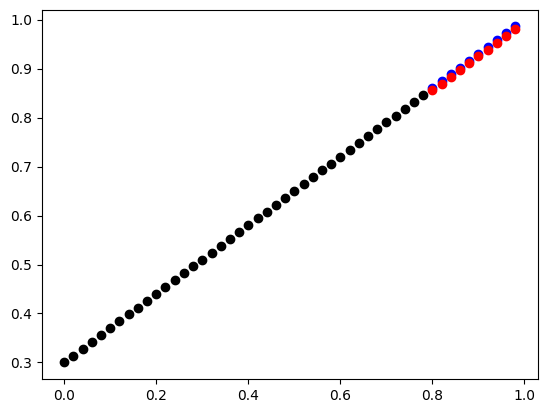

In [19]:
plt.scatter(X_train, y_train, c='black')
plt.scatter(X_test, y_test, c='blue')
plt.scatter(X_test, y_preds_new, c='red')

plt.show()

## Saving a model

In [20]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "02_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print("Saving to:", MODEL_SAVE_PATH)

torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving to: models/02_pytorch_workflow_model.pth


## Loading a model

In [22]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [23]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [24]:
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])